# Clustering Prep: restore `payment_type` and `ProductCD`

Подготовка данных с использованием готовых pipeline и восстановлением кластеризационных фич в двух вариантах: raw и normalized.

In [15]:
import os
import pandas as pd
import numpy as np
import joblib

from IEEEPipelineModules import FraudPreprocessor 
from TaxiPipelineModules import BinaryCategoryEncoder, DatetimeFeaturesTransformer, FrequencyEncoder, Log1pTransformer, NonNegativeCleaner, QuantileClipper, RangeClipper, TaxiSimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import AgglomerativeClustering
from sklearn.manifold import TSNE

from scipy.spatial.distance import pdist
from sklearn.decomposition import PCA as SklearnPCA

import time
from sklearn.metrics import silhouette_score, homogeneity_score, completeness_score, v_measure_score


In [16]:
ROOT = "/home/jupyter/datasets/"
IEEE_DIR = os.path.join(ROOT, "ieee-fraud-detection")
TAXI_DIR = os.path.join(ROOT, "nyc-taxi-small-public")

IEEE_TRAIN = os.path.join(IEEE_DIR, "train_public.csv")
IEEE_TEST = os.path.join(IEEE_DIR, "test_public.csv")
TAXI_X_TRAIN = os.path.join(TAXI_DIR, "X_train_public.csv")
TAXI_Y_TRAIN = os.path.join(TAXI_DIR, "y_train_public.csv")
TAXI_X_TEST = os.path.join(TAXI_DIR, "X_test_public.csv")

PIPELINE_TAXI_PATH = "taxi_pipeline.joblib"
PIPELINE_IEEE_PATH = "pipeline_ieee.pkl"

In [17]:
X_train_taxi = pd.read_csv(TAXI_X_TRAIN, low_memory=False)
X_test_taxi = pd.read_csv(TAXI_X_TEST, low_memory=False)
y_train_taxi = pd.read_csv(TAXI_Y_TRAIN)["trip_duration_sec"].values

train_ieee = pd.read_csv(IEEE_TRAIN, low_memory=False)
test_ieee = pd.read_csv(IEEE_TEST, low_memory=False)

X_ieee_train_raw = train_ieee.drop(columns=["TransactionID", "isFraud"])
y_ieee_train = train_ieee["isFraud"].astype(int)
X_ieee_test_raw = test_ieee.drop(columns=["TransactionID"], errors="ignore")

# pipeline_taxi = joblib.load(PIPELINE_TAXI_PATH)
# pipeline_ieee = joblib.load(PIPELINE_IEEE_PATH)

# print("Taxi train/test:", X_train_taxi.shape, X_test_taxi.shape)
# print("IEEE train/test:", X_ieee_train_raw.shape, X_ieee_test_raw.shape)

In [18]:
# def transformed_to_df(pipeline, X):
#     Xt = pipeline.transform(X)
#     idx = X.index

#     feature_names = None
#     try:
#         feature_names = pipeline.get_feature_names_out()
#     except Exception:
#         try:
#             if "feat_prep" in pipeline.named_steps:
#                 feature_names = pipeline.named_steps["feat_prep"].get_feature_names_out()
#             elif "transform" in pipeline.named_steps:
#                 feature_names = pipeline.named_steps["transform"].get_feature_names_out()
#         except Exception:
#             feature_names = None

#     if feature_names is None:
#         feature_names = [f"f_{i}" for i in range(Xt.shape[1])]

#     Xt_df = pd.DataFrame(Xt, index=idx, columns=list(feature_names))
#     assert len(Xt_df) == len(X), "Row count mismatch after transform"
#     assert Xt_df.index.equals(idx), "Index mismatch after transform"
#     return Xt_df


# def drop_ohe_columns(df, prefixes):
#     drop_cols = []
#     for pref in prefixes:
#         drop_cols.extend([c for c in df.columns if c.startswith(pref)])
#     if drop_cols:
#         return df.drop(columns=sorted(set(drop_cols)))
#     return df

In [19]:
# # Taxi: restore payment_type raw and normalized
# taxi_payment_raw_train = X_train_taxi["payment_type"].copy()
# taxi_payment_raw_test = X_test_taxi["payment_type"].copy()

# taxi_df_prep_train = pipeline_taxi.named_steps["df_prep"].transform(X_train_taxi)
# taxi_df_prep_test = pipeline_taxi.named_steps["df_prep"].transform(X_test_taxi)
# taxi_payment_norm_train = taxi_df_prep_train["payment_type"].copy()
# taxi_payment_norm_test = taxi_df_prep_test["payment_type"].copy()

# X_taxi_train_transformed = transformed_to_df(pipeline_taxi, X_train_taxi)
# X_taxi_test_transformed = transformed_to_df(pipeline_taxi, X_test_taxi)
# X_taxi_train_transformed = drop_ohe_columns(X_taxi_train_transformed, ["payment_type_", "cat__payment_type_"])
# X_taxi_test_transformed = drop_ohe_columns(X_taxi_test_transformed, ["payment_type_", "cat__payment_type_"])

# X_taxi_train_cluster = X_taxi_train_transformed.join(taxi_payment_raw_train.rename("payment_type_raw")).join(taxi_payment_norm_train.rename("payment_type_normalized"))
# X_taxi_test_cluster = X_taxi_test_transformed.join(taxi_payment_raw_test.rename("payment_type_raw")).join(taxi_payment_norm_test.rename("payment_type_normalized"))

In [20]:
# # IEEE: restore ProductCD raw and normalized
# ieee_product_raw_train = X_ieee_train_raw["ProductCD"].copy()
# ieee_product_raw_test = X_ieee_test_raw["ProductCD"].copy()

# ieee_prep_train = pipeline_ieee.named_steps["preprocess"].transform(X_ieee_train_raw)
# ieee_prep_test = pipeline_ieee.named_steps["preprocess"].transform(X_ieee_test_raw)
# ieee_product_norm_train = ieee_prep_train["ProductCD"].copy()
# ieee_product_norm_test = ieee_prep_test["ProductCD"].copy()

# X_ieee_train_transformed = transformed_to_df(pipeline_ieee, X_ieee_train_raw)
# X_ieee_test_transformed = transformed_to_df(pipeline_ieee, X_ieee_test_raw)
# X_ieee_train_transformed = drop_ohe_columns(X_ieee_train_transformed, ["ProductCD_", "cat__ProductCD_"])
# X_ieee_test_transformed = drop_ohe_columns(X_ieee_test_transformed, ["ProductCD_", "cat__ProductCD_"])

# X_ieee_train_cluster = X_ieee_train_transformed.join(ieee_product_raw_train.rename("ProductCD_raw")).join(ieee_product_norm_train.rename("ProductCD_normalized"))
# X_ieee_test_cluster = X_ieee_test_transformed.join(ieee_product_raw_test.rename("ProductCD_raw")).join(ieee_product_norm_test.rename("ProductCD_normalized"))

In [21]:
# # Consistency checks
# assert X_taxi_train_cluster.index.equals(X_train_taxi.index)
# assert X_taxi_test_cluster.index.equals(X_test_taxi.index)
# assert X_ieee_train_cluster.index.equals(X_ieee_train_raw.index)
# assert X_ieee_test_cluster.index.equals(X_ieee_test_raw.index)

# assert len(X_taxi_train_cluster) == len(X_train_taxi)
# assert len(X_taxi_test_cluster) == len(X_test_taxi)
# assert len(X_ieee_train_cluster) == len(X_ieee_train_raw)
# assert len(X_ieee_test_cluster) == len(X_ieee_test_raw)

# assert not X_taxi_train_cluster.index.has_duplicates
# assert not X_taxi_test_cluster.index.has_duplicates
# assert not X_ieee_train_cluster.index.has_duplicates
# assert not X_ieee_test_cluster.index.has_duplicates

# print("Taxi cluster train shape:", X_taxi_train_cluster.shape)
# print("Taxi payment nunique raw/normalized:", X_taxi_train_cluster["payment_type_raw"].nunique(dropna=False), X_taxi_train_cluster["payment_type_normalized"].nunique(dropna=False))
# display(X_taxi_train_cluster[["payment_type_raw", "payment_type_normalized"]].head())

# print("IEEE cluster train shape:", X_ieee_train_cluster.shape)
# print("IEEE ProductCD nunique raw/normalized:", X_ieee_train_cluster["ProductCD_raw"].nunique(dropna=False), X_ieee_train_cluster["ProductCD_normalized"].nunique(dropna=False))
# display(X_ieee_train_cluster[["ProductCD_raw", "ProductCD_normalized"]].head())

In [22]:
# # Save transformed tables to avoid rerunning pipelines
# OUTPUT_DIR = "cluster_ready_tables"
# os.makedirs(OUTPUT_DIR, exist_ok=True)

# paths = {
#     "taxi_train": os.path.join(OUTPUT_DIR, "taxi_train_cluster.parquet"),
#     "taxi_test": os.path.join(OUTPUT_DIR, "taxi_test_cluster.parquet"),
#     "ieee_train": os.path.join(OUTPUT_DIR, "ieee_train_cluster.parquet"),
#     "ieee_test": os.path.join(OUTPUT_DIR, "ieee_test_cluster.parquet"),
# }

# try:
#     X_taxi_train_cluster.to_parquet(paths["taxi_train"], index=True)
#     X_taxi_test_cluster.to_parquet(paths["taxi_test"], index=True)
#     X_ieee_train_cluster.to_parquet(paths["ieee_train"], index=True)
#     X_ieee_test_cluster.to_parquet(paths["ieee_test"], index=True)
#     print("Saved parquet files:")
#     for name, p in paths.items():
#         print(f"- {name}: {p}")
# except Exception as e:
#     print("Parquet save failed, fallback to compressed CSV. Reason:", str(e))

#     paths = {
#         "taxi_train": os.path.join(OUTPUT_DIR, "taxi_train_cluster.csv.gz"),
#         "taxi_test": os.path.join(OUTPUT_DIR, "taxi_test_cluster.csv.gz"),
#         "ieee_train": os.path.join(OUTPUT_DIR, "ieee_train_cluster.csv.gz"),
#         "ieee_test": os.path.join(OUTPUT_DIR, "ieee_test_cluster.csv.gz"),
#     }

#     X_taxi_train_cluster.to_csv(paths["taxi_train"], index=True, compression="gzip")
#     X_taxi_test_cluster.to_csv(paths["taxi_test"], index=True, compression="gzip")
#     X_ieee_train_cluster.to_csv(paths["ieee_train"], index=True, compression="gzip")
#     X_ieee_test_cluster.to_csv(paths["ieee_test"], index=True, compression="gzip")

#     print("Saved compressed CSV files:")
#     for name, p in paths.items():
#         print(f"- {name}: {p}")

In [23]:
X_ieee_cluster = pd.read_parquet("/home/jupyter/project/Homework4/cluster_ready_tables/ieee_train_cluster.parquet")
X_taxi_cluster = pd.read_parquet("/home/jupyter/project/Homework4/cluster_ready_tables/taxi_train_cluster.parquet")

In [24]:
X_ieee_cluster = X_ieee_cluster.drop(columns=["ProductCD_raw"])
X_taxi_cluster = X_taxi_cluster.drop(columns=["payment_type_raw"])

In [25]:
X_ieee_cluster["ProductCD_normalized"].unique(), X_taxi_cluster["tpep_pickup_dayofweek"].unique()

(array(['W', 'H', 'C', 'S', 'R'], dtype=object),
 array([-1.59987909,  1.52787786, -0.03600062, -1.07858627, -0.55729344,
         0.48529221,  1.00658503]))

In [26]:
X_ieee_cluster["isFraud"] = pd.Series(y_ieee_train.values, index=X_ieee_cluster.index)

In [27]:
X_taxi_cluster["TripDuration"] = pd.Series(y_train_taxi, index=X_taxi_cluster.index)

In [28]:
def profile_post_pipeline_discrete(df, dataset_name, nunique_threshold=20):
    obj_cols = list(df.select_dtypes(include=["object", "category"]).columns)
    num_cols = [
        c for c in df.select_dtypes(include=[np.number]).columns
        if df[c].nunique(dropna=False) <= nunique_threshold
    ]
    candidate_cols = list(dict.fromkeys(obj_cols + num_cols))

    rows = []
    n = len(df)
    for c in candidate_cols:
        s = df[c]
        vc = s.value_counts(dropna=False)
        max_share = float(vc.iloc[0] / n) if len(vc) else np.nan
        rows.append({
            "dataset": dataset_name,
            "feature": c,
            "dtype": str(s.dtype),
            "nunique": int(s.nunique(dropna=False)),
            "max_share": max_share,
            "missing_pct": float(s.isna().mean() * 100),
        })

    out = pd.DataFrame(rows).sort_values(["max_share", "nunique"], ascending=[True, True]).reset_index(drop=True)
    return out


def summarize_balanced_candidates(profile_df, nunique_cutoff=10, max_share_cutoff=0.60):
    return profile_df[
        (profile_df["nunique"] <= nunique_cutoff) & (profile_df["max_share"] <= max_share_cutoff)
    ].sort_values(["max_share", "nunique"], ascending=[True, True]).reset_index(drop=True)


taxi_post_profile = profile_post_pipeline_discrete(X_taxi_cluster, "taxi_post")
ieee_post_profile = profile_post_pipeline_discrete(X_ieee_cluster, "ieee_post")

print("Taxi post-pipeline discrete profile (top 30 by lower imbalance):")
display(taxi_post_profile.head(30))
print("IEEE post-pipeline discrete profile (top 30 by lower imbalance):")
display(ieee_post_profile.head(30))

NUNIQUE_CUTOFF = 10
MAX_SHARE_CUTOFF = 0.60

balanced_taxi = summarize_balanced_candidates(taxi_post_profile, NUNIQUE_CUTOFF, MAX_SHARE_CUTOFF)
balanced_ieee = summarize_balanced_candidates(ieee_post_profile, NUNIQUE_CUTOFF, MAX_SHARE_CUTOFF)

print(f"\nBalanced low-cardinality candidates (nunique <= {NUNIQUE_CUTOFF}, max_share <= {MAX_SHARE_CUTOFF}):")
print("Taxi count:", len(balanced_taxi))
print("IEEE count:", len(balanced_ieee))

if len(balanced_taxi) > 0:
    print("Taxi candidates:")
    display(balanced_taxi)
if len(balanced_ieee) > 0:
    print("IEEE candidates:")
    display(balanced_ieee)

if len(balanced_taxi) == 0 and len(balanced_ieee) == 0:
    print("Conclusion: in post-pipeline data we do not observe features that are both low-cardinality and well-balanced under this strict criterion.")
else:
    print("Conclusion: only a very limited number of features satisfy the strict balance criterion.")

Taxi post-pipeline discrete profile (top 30 by lower imbalance):


,dataset,feature,dtype,nunique,max_share,missing_pct
0,taxi_post,tpep_pickup_dayofweek,float64,7,0.161575,0.0
1,taxi_post,tpep_pickup_dow_sin,float64,7,0.161575,0.0
2,taxi_post,tpep_pickup_dow_cos,float64,6,0.311819,0.0
3,taxi_post,tpep_pickup_month,float64,5,0.374946,0.0
4,taxi_post,tpep_pickup_month_sin,float64,5,0.374946,0.0
5,taxi_post,tpep_pickup_month_cos,float64,5,0.374946,0.0
6,taxi_post,tpep_pickup_is_weekend,float64,2,0.715855,0.0
7,taxi_post,payment_type_normalized,int64,5,0.759824,0.0
8,taxi_post,passenger_count,float64,6,0.803529,0.0
9,taxi_post,RatecodeID_1.0,float64,2,0.946806,0.0


IEEE post-pipeline discrete profile (top 30 by lower imbalance):


,dataset,feature,dtype,nunique,max_share,missing_pct
0,ieee_post,cat__M1_missing,float64,2,0.504401,0.0
1,ieee_post,cat__M2_missing,float64,2,0.504401,0.0
2,ieee_post,cat__M3_missing,float64,2,0.504401,0.0
3,ieee_post,cat__M1_T,float64,2,0.504445,0.0
4,ieee_post,cat__M4_missing,float64,2,0.519103,0.0
5,ieee_post,cat__M2_T,float64,2,0.555477,0.0
6,ieee_post,num__V75,float64,5,0.591505,0.0
7,ieee_post,num__V12,float64,4,0.594924,0.0
8,ieee_post,cat__M5_missing,float64,2,0.600116,0.0
9,ieee_post,num__V53,float64,6,0.605852,0.0



Balanced low-cardinality candidates (nunique <= 10, max_share <= 0.6):
Taxi count: 6
IEEE count: 8
Taxi candidates:


,dataset,feature,dtype,nunique,max_share,missing_pct
0,taxi_post,tpep_pickup_dayofweek,float64,7,0.161575,0.0
1,taxi_post,tpep_pickup_dow_sin,float64,7,0.161575,0.0
2,taxi_post,tpep_pickup_dow_cos,float64,6,0.311819,0.0
3,taxi_post,tpep_pickup_month,float64,5,0.374946,0.0
4,taxi_post,tpep_pickup_month_sin,float64,5,0.374946,0.0
5,taxi_post,tpep_pickup_month_cos,float64,5,0.374946,0.0


IEEE candidates:


,dataset,feature,dtype,nunique,max_share,missing_pct
0,ieee_post,cat__M1_missing,float64,2,0.504401,0.0
1,ieee_post,cat__M2_missing,float64,2,0.504401,0.0
2,ieee_post,cat__M3_missing,float64,2,0.504401,0.0
3,ieee_post,cat__M1_T,float64,2,0.504445,0.0
4,ieee_post,cat__M4_missing,float64,2,0.519103,0.0
5,ieee_post,cat__M2_T,float64,2,0.555477,0.0
6,ieee_post,num__V75,float64,5,0.591505,0.0
7,ieee_post,num__V12,float64,4,0.594924,0.0


Conclusion: only a very limited number of features satisfy the strict balance criterion.


## Implementation of K-means algorithm

In [29]:
class KMeans:
    def __init__(self, n_clusters=8, n_init=10,
                 max_iter=300, tol=1e-4, random_state=None):
        self.n_clusters = n_clusters
        self.n_init = n_init
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state

        self.cluster_centers_ = None
        self.labels_ = None
        self.inertia_ = None

    def fit(self, X):
        X = np.asarray(X)
        rng = np.random.default_rng(self.random_state)

        best_inertia = np.inf
        best_centroids = None
        best_labels = None

        for _ in range(self.n_init):
            indices = rng.choice(len(X), self.n_clusters, replace=False)
            centroids = X[indices]

            labels, inertia, final_centroids = self._fit_single(X, centroids)

            if inertia < best_inertia:
                best_inertia = inertia
                best_centroids = final_centroids
                best_labels = labels

        self.cluster_centers_ = best_centroids
        self.labels_ = best_labels
        self.inertia_ = best_inertia
        return self

    def predict(self, X):
        X = np.asarray(X)
        dists_sq = ((X[:, np.newaxis] - self.cluster_centers_) ** 2).sum(axis=2)
        return np.argmin(dists_sq, axis=1)

    def _fit_single(self, X, centroids):
        for _ in range(self.max_iter):
            dists_sq = ((X[:, np.newaxis] - centroids) ** 2).sum(axis=2)
            labels = np.argmin(dists_sq, axis=1)

            # Vectorized centroid recomputation (faster than Python loop per cluster)
            new_centroids = centroids.copy()
            counts = np.bincount(labels, minlength=self.n_clusters)
            sums = np.zeros((self.n_clusters, X.shape[1]), dtype=X.dtype)
            np.add.at(sums, labels, X)

            non_empty = counts > 0
            new_centroids[non_empty] = sums[non_empty] / counts[non_empty, None]

            if np.linalg.norm(new_centroids - centroids) < self.tol:
                centroids = new_centroids
                break
            centroids = new_centroids

        final_dists_sq = ((X[:, np.newaxis] - centroids) ** 2).sum(axis=2)
        labels = np.argmin(final_dists_sq, axis=1)
        inertia = np.sum(np.min(final_dists_sq, axis=1))

        return labels, inertia, centroids

    def __repr__(self):
        return (
            f"KMeans(n_clusters={self.n_clusters}, n_init={self.n_init}, "
            f"max_iter={self.max_iter}, tol={self.tol})"
        )

## Implementation of PCA algorithm

In [30]:
class PCA:
    def __init__(self, n_components=None, explained_variance_ratio_threshold=0.95):
        self.n_components = n_components
        self.threshold = explained_variance_ratio_threshold
        self.components_ = None
        self.explained_variance_ = None
        self.explained_variance_ratio_ = None
        self.mean_ = None

    def fit(self, X):
        X = np.asarray(X)
        self.mean_ = X.mean(axis=0)
        X_centered = X - self.mean_
        
        cov_matrix = np.cov(X_centered, rowvar=False)
        
        eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
        
        idx = np.argsort(eigenvalues)[::-1]
        eigenvalues = eigenvalues[idx]
        eigenvectors = eigenvectors[:, idx]
        
        total_variance = eigenvalues.sum()
        self.explained_variance_ = eigenvalues
        self.explained_variance_ratio_ = eigenvalues / total_variance
        
        if self.n_components is None:
            cumsum = np.cumsum(self.explained_variance_ratio_)
            self.n_components = np.argmax(cumsum >= self.threshold) + 1
        
        self.components_ = eigenvectors[:, :self.n_components]
        return self

    def transform(self, X):
        X_centered = X - self.mean_
        return X_centered @ self.components_

    def fit_transform(self, X):
        return self.fit(X).transform(X)

    def inverse_transform(self, X_reduced):
        return X_reduced @ self.components_.T + self.mean_

In [33]:
RANDOM_STATE = 42
K_VALUES = list(range(2, 9))
DISTANCE_METRIC = "euclidean"

FAST_MODE = True
if FAST_MODE:
    KMEANS_N_INIT = 3
    KMEANS_MAX_ITER = 120
    KMEANS_TOL = 1e-3
    MAX_CLUSTER_SAMPLES = 10000
    MAX_SILHOUETTE_SAMPLES = None
    KMEANS_DTYPE = np.float64
else:
    KMEANS_N_INIT = 10
    KMEANS_MAX_ITER = 300
    KMEANS_TOL = 1e-4
    MAX_CLUSTER_SAMPLES = None
    MAX_SILHOUETTE_SAMPLES = None
    KMEANS_DTYPE = np.float64

metrics_dir = "cluster_metrics"
os.makedirs(metrics_dir, exist_ok=True)

datasets_cfg = [
    {
        "dataset": "taxi",
        "df": X_taxi_cluster,
        "pseudo_target_col": "tpep_pickup_dayofweek",
        "include_cols": ["y"],
    },
    {
        "dataset": "ieee",
        "df": X_ieee_cluster,
        "pseudo_target_col": "ProductCD_normalized",
        "include_cols": ["y"],
    },
]

saved_files = []

def prepare_inputs(df, pseudo_target_col, include_cols=None, max_samples=MAX_CLUSTER_SAMPLES, random_state=RANDOM_STATE):
    include_cols = include_cols or []

    numeric_df = df.select_dtypes(include=[np.number]).copy()

    selected_cols = list(numeric_df.columns)
    if include_cols:
        selected_cols = [c for c in selected_cols if c in set(selected_cols).union(include_cols)]

    X = numeric_df[selected_cols].copy()

    y_pseudo = df[pseudo_target_col].astype(str)

    valid_mask = (~X.isna().any(axis=1)) & (~y_pseudo.isna())
    X = X.loc[valid_mask]
    y_pseudo = y_pseudo.loc[valid_mask]

    if max_samples is not None:
        if len(X) > max_samples:
            sampled_idx = X.sample(n=max_samples, random_state=random_state).index
            X = X.loc[sampled_idx]
            y_pseudo = y_pseudo.loc[sampled_idx]

    y_codes = pd.Categorical(y_pseudo).codes

    return X, y_pseudo, y_codes



def cluster_distance_metrics(X_np, labels, centroids):
    assigned_centroids = centroids[labels]
    intra = np.linalg.norm(X_np - assigned_centroids, axis=1)
    avg_intra = float(np.mean(intra))
    if len(centroids) > 1:
        inter = pdist(centroids, metric="euclidean")
        avg_inter = float(np.mean(inter)) if len(inter) else np.nan
    else:
        avg_inter = np.nan
    return avg_intra, avg_inter


def safe_silhouette(X_np, labels, max_samples=MAX_SILHOUETTE_SAMPLES, random_state=RANDOM_STATE):
    unique_labels = np.unique(labels)
    if len(unique_labels) < 2:
        return np.nan
    if max_samples is not None:
        if len(X_np) > max_samples:
            rng = np.random.default_rng(random_state)
            sample_idx = rng.choice(len(X_np), size=max_samples, replace=False)
            X_sample = X_np[sample_idx]
            labels_sample = labels[sample_idx]

            if len(np.unique(labels_sample)) < 2:
                return np.nan

            return float(silhouette_score(X_sample, labels_sample, metric="euclidean"))

    return float(silhouette_score(X_np, labels, metric="euclidean"))

In [34]:
experiment_rows = []
cluster_outputs = {}

total_runs = len(datasets_cfg) * len(K_VALUES)
done_runs = 0
global_t0 = time.time()

print(f"[START] Total runs: {total_runs} ({len(datasets_cfg)} datasets x {len(K_VALUES)} k-values)")
print(
    f"[SETTINGS] FAST_MODE={FAST_MODE}, n_init={KMEANS_N_INIT}, "
    f"max_iter={KMEANS_MAX_ITER}, tol={KMEANS_TOL}, dtype={np.dtype(KMEANS_DTYPE).name}, "
    f"max_cluster_samples={MAX_CLUSTER_SAMPLES}, max_silhouette_samples={MAX_SILHOUETTE_SAMPLES}"
)

for cfg_idx, cfg in enumerate(datasets_cfg, start=1):
    dataset_name = cfg["dataset"]
    ds_t0 = time.time()

    X_df, y_pseudo, y_codes = prepare_inputs(
        cfg["df"],
        pseudo_target_col=cfg["pseudo_target_col"],
        include_cols=cfg["include_cols"],
    )

    X_np = X_df.to_numpy(dtype=KMEANS_DTYPE)
    print(
        f"[DATASET {cfg_idx}/{len(datasets_cfg)}] {dataset_name}: rows={len(X_df)}, "
        f"features={X_np.shape[1]}, dtype={X_np.dtype}"
    )

    for k_idx, k in enumerate(K_VALUES, start=1):
        run_t0 = time.time()
        print(f"  -> Running {dataset_name} | k={k} ({k_idx}/{len(K_VALUES)})")

        model = KMeans(
            n_clusters=k,
            n_init=KMEANS_N_INIT,
            max_iter=KMEANS_MAX_ITER,
            tol=KMEANS_TOL,
            random_state=RANDOM_STATE,
        )
        model.fit(X_np)
        labels = model.labels_
        centroids = model.cluster_centers_

        avg_intra, avg_inter = cluster_distance_metrics(X_np, labels, centroids)
        sil = safe_silhouette(X_np, labels)

        hom = float(homogeneity_score(y_pseudo, labels))
        comp = float(completeness_score(y_pseudo, labels))
        vms = float(v_measure_score(y_pseudo, labels))

        cluster_sizes = np.bincount(labels, minlength=k)
        cluster_shares = cluster_sizes / cluster_sizes.sum()
        largest_cluster_share = float(cluster_shares.max())
        smallest_nonzero_cluster_share = float(cluster_shares[cluster_shares > 0].min())
        imbalance_ratio = float((cluster_sizes.max() / cluster_sizes[cluster_sizes > 0].min()))

        row = {
            "dataset": dataset_name,
            "algorithm": "kmeans",
            "distance_metric": DISTANCE_METRIC,
            "hyperparameters": (
                f"k={k},n_init={KMEANS_N_INIT},max_iter={KMEANS_MAX_ITER},tol={KMEANS_TOL},"
                f"dtype={np.dtype(KMEANS_DTYPE).name},fast_mode={FAST_MODE}"
            ),
            "random_state": RANDOM_STATE,
            "k": k,
            "avg_intra_cluster_distance": avg_intra,
            "avg_inter_cluster_distance": avg_inter,
            "silhouette": sil,
            "homogeneity": hom,
            "completeness": comp,
            "v_measure": vms,
            "largest_cluster_share": largest_cluster_share,
            "smallest_nonzero_cluster_share": smallest_nonzero_cluster_share,
            "cluster_imbalance_ratio": imbalance_ratio,
        }
        experiment_rows.append(row)

        cluster_outputs[(dataset_name, k)] = {
            "X_df": X_df,
            "X_np": X_np,
            "y_pseudo": y_pseudo,
            "y_codes": y_codes,
            "labels": labels,
            "centroids": centroids,
        }

        done_runs += 1
        elapsed = time.time() - global_t0
        avg_per_run = elapsed / done_runs
        remaining_runs = total_runs - done_runs
        eta_sec = avg_per_run * remaining_runs
        run_sec = time.time() - run_t0

        print(
            f"     done {done_runs}/{total_runs} | run_time={run_sec:.2f}s | "
            f"sil={sil:.4f} | v_measure={vms:.4f} | "
            f"max_share={largest_cluster_share:.3f} | imbalance={imbalance_ratio:.1f}x | ETA~{eta_sec:.1f}s"
        )
        if largest_cluster_share >= 0.80:
            print(
                f"     [WARN] Strong cluster imbalance at {dataset_name}, k={k}: "
                f"largest cluster has {largest_cluster_share:.1%} of points"
            )

    ds_elapsed = time.time() - ds_t0
    print(f"[DATASET DONE] {dataset_name} in {ds_elapsed:.1f}s")

print(f"[ALL DONE] {total_runs} runs finished in {time.time() - global_t0:.1f}s")

experiments_df = pd.DataFrame(experiment_rows)
experiments_df = experiments_df.sort_values(["dataset", "silhouette", "v_measure"], ascending=[True, False, False]).reset_index(drop=True)

print("Unified experiment table shape:", experiments_df.shape)
display(experiments_df.head(20))

print("Top-3 by silhouette for each dataset:")
display(experiments_df.groupby("dataset", group_keys=False).head(3))

metrics_dir = "cluster_metrics"
os.makedirs(metrics_dir, exist_ok=True)

p = os.path.join(metrics_dir, "baseline_experiments_metrics.csv")
experiments_df.to_csv(p, index=False)
saved_files.append(p)

[START] Total runs: 14 (2 datasets x 7 k-values)
[SETTINGS] FAST_MODE=True, n_init=3, max_iter=120, tol=0.001, dtype=float64, max_cluster_samples=10000, max_silhouette_samples=None
[DATASET 1/2] taxi: rows=10000, features=27, dtype=float64
  -> Running taxi | k=2 (1/7)
     done 1/14 | run_time=2.23s | sil=0.9912 | v_measure=0.0005 | max_share=0.999 | imbalance=1427.6x | ETA~192.1s
     [WARN] Strong cluster imbalance at taxi, k=2: largest cluster has 99.9% of points
  -> Running taxi | k=3 (2/7)
     done 2/14 | run_time=2.75s | sil=0.6892 | v_measure=0.0010 | max_share=0.852 | imbalance=1216.4x | ETA~105.2s
     [WARN] Strong cluster imbalance at taxi, k=3: largest cluster has 85.2% of points
  -> Running taxi | k=4 (3/7)
     done 3/14 | run_time=3.34s | sil=0.6046 | v_measure=0.0022 | max_share=0.661 | imbalance=944.4x | ETA~76.5s
  -> Running taxi | k=5 (4/7)
     done 4/14 | run_time=5.36s | sil=0.5755 | v_measure=0.0024 | max_share=0.546 | imbalance=780.4x | ETA~65.6s
  -> Runni

,dataset,algorithm,distance_metric,hyperparameters,random_state,k,avg_intra_cluster_distance,avg_inter_cluster_distance,silhouette,homogeneity,completeness,v_measure,largest_cluster_share,smallest_nonzero_cluster_share,cluster_imbalance_ratio
0,ieee,kmeans,euclidean,"k=3,n_init=3,max_iter=120,tol=0.001,dtype=floa...",42,3,20118.990204,448986.303182,0.899023,0.130725,0.471077,0.204657,0.9435,0.0171,55.175439
1,ieee,kmeans,euclidean,"k=2,n_init=3,max_iter=120,tol=0.001,dtype=floa...",42,2,30723.780264,328180.762721,0.873649,0.076922,0.414926,0.129784,0.9599,0.0401,23.937656
2,ieee,kmeans,euclidean,"k=4,n_init=3,max_iter=120,tol=0.001,dtype=floa...",42,4,18878.255531,437051.961490,0.869060,0.184044,0.459845,0.262877,0.9170,0.0149,61.543624
3,ieee,kmeans,euclidean,"k=7,n_init=3,max_iter=120,tol=0.001,dtype=floa...",42,7,10794.281972,370059.346598,0.854415,0.374244,0.501212,0.428521,0.8331,0.0008,1041.375000
4,ieee,kmeans,euclidean,"k=8,n_init=3,max_iter=120,tol=0.001,dtype=floa...",42,8,8629.948538,355857.113166,0.850030,0.447671,0.489600,0.467697,0.8079,0.0069,117.086957
5,ieee,kmeans,euclidean,"k=6,n_init=3,max_iter=120,tol=0.001,dtype=floa...",42,6,12952.608287,357895.609338,0.845577,0.355505,0.514919,0.420614,0.8413,0.0008,1051.625000
6,ieee,kmeans,euclidean,"k=5,n_init=3,max_iter=120,tol=0.001,dtype=floa...",42,5,13010.655109,399208.144352,0.845521,0.352687,0.516081,0.419018,0.8421,0.0143,58.888112
7,taxi,kmeans,euclidean,"k=2,n_init=3,max_iter=120,tol=0.001,dtype=floa...",42,2,526.309846,84216.623780,0.991245,0.000236,0.079231,0.000471,0.9993,0.0007,1427.571429
8,taxi,kmeans,euclidean,"k=3,n_init=3,max_iter=120,tol=0.001,dtype=floa...",42,3,348.149555,56309.161745,0.689209,0.000621,0.002838,0.001019,0.8515,0.0007,1216.428571
9,taxi,kmeans,euclidean,"k=4,n_init=3,max_iter=120,tol=0.001,dtype=floa...",42,4,248.475162,42611.710560,0.604632,0.001527,0.003722,0.002165,0.6611,0.0007,944.428571


Top-3 by silhouette for each dataset:


,dataset,algorithm,distance_metric,hyperparameters,random_state,k,avg_intra_cluster_distance,avg_inter_cluster_distance,silhouette,homogeneity,completeness,v_measure,largest_cluster_share,smallest_nonzero_cluster_share,cluster_imbalance_ratio
0,ieee,kmeans,euclidean,"k=3,n_init=3,max_iter=120,tol=0.001,dtype=floa...",42,3,20118.990204,448986.303182,0.899023,0.130725,0.471077,0.204657,0.9435,0.0171,55.175439
1,ieee,kmeans,euclidean,"k=2,n_init=3,max_iter=120,tol=0.001,dtype=floa...",42,2,30723.780264,328180.762721,0.873649,0.076922,0.414926,0.129784,0.9599,0.0401,23.937656
2,ieee,kmeans,euclidean,"k=4,n_init=3,max_iter=120,tol=0.001,dtype=floa...",42,4,18878.255531,437051.961490,0.869060,0.184044,0.459845,0.262877,0.9170,0.0149,61.543624
7,taxi,kmeans,euclidean,"k=2,n_init=3,max_iter=120,tol=0.001,dtype=floa...",42,2,526.309846,84216.623780,0.991245,0.000236,0.079231,0.000471,0.9993,0.0007,1427.571429
8,taxi,kmeans,euclidean,"k=3,n_init=3,max_iter=120,tol=0.001,dtype=floa...",42,3,348.149555,56309.161745,0.689209,0.000621,0.002838,0.001019,0.8515,0.0007,1216.428571
9,taxi,kmeans,euclidean,"k=4,n_init=3,max_iter=120,tol=0.001,dtype=floa...",42,4,248.475162,42611.710560,0.604632,0.001527,0.003722,0.002165,0.6611,0.0007,944.428571


,dataset,k,silhouette,v_measure
0,taxi,7,0.545115,0.003231
1,ieee,5,0.845521,0.419018


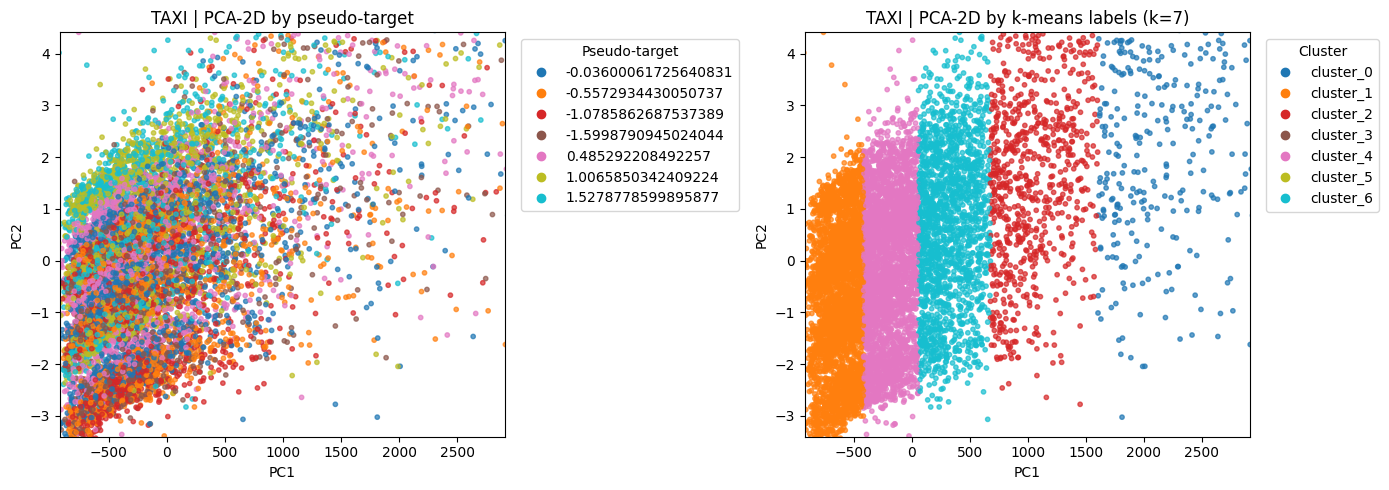

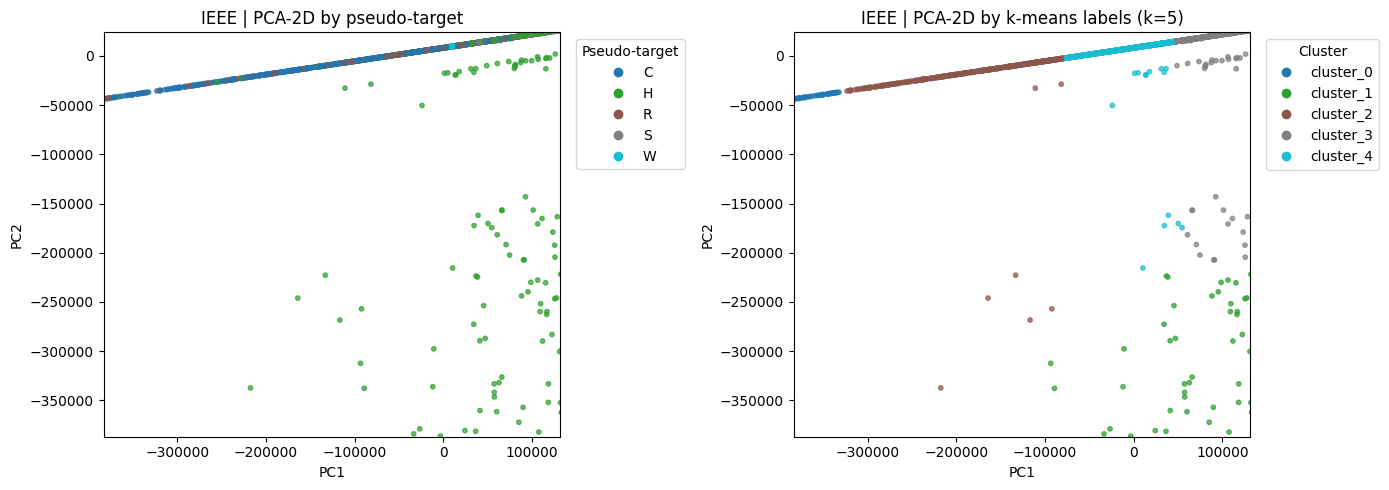

In [35]:
target_k_by_dataset = {
    "taxi": X_taxi_cluster["tpep_pickup_dayofweek"].nunique(),
    "ieee": X_ieee_cluster["ProductCD_normalized"].nunique(),
}

rows = []
for ds, k_target in target_k_by_dataset.items():
    sub = experiments_df[(experiments_df["dataset"] == ds) & (experiments_df["k"] == k_target)]
    if len(sub) == 0:
        print(f"[WARN] Нет строки для dataset={ds}, k={k_target}. Проверь диапазон K_VALUES.")
        continue
    rows.append(sub.iloc[0][["dataset", "k", "silhouette", "v_measure"]])

best_cfg = pd.DataFrame(rows).reset_index(drop=True)
display(best_cfg)


for _, row in best_cfg.iterrows():
    dataset_name = row["dataset"]
    k_best = int(row["k"])

    payload = cluster_outputs[(dataset_name, k_best)]
    X_np = payload["X_np"]
    y_pseudo = payload["y_pseudo"]
    labels = payload["labels"]

    pca_2d = PCA(n_components=2)
    X_2d = pca_2d.fit_transform(X_np)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ax1 = axes[0]
    pseudo_cat = pd.Categorical(y_pseudo)
    sc1 = ax1.scatter(X_2d[:, 0], X_2d[:, 1], c=pseudo_cat.codes, s=10, alpha=0.7, cmap="tab10")
    ax1.set_title(f"{dataset_name.upper()} | PCA-2D by pseudo-target")
    ax1.set_xlabel("PC1")
    ax1.set_ylabel("PC2")
    
    x1, x2 = np.percentile(X_2d[:, 0], [1, 99])
    y1, y2 = np.percentile(X_2d[:, 1], [1, 99])
    ax1.set_xlim(x1, x2)
    ax1.set_ylim(y1, y2)

    pseudo_handles = []
    for i, cat_name in enumerate(pseudo_cat.categories):
        pseudo_handles.append(
            plt.Line2D([], [], marker="o", linestyle="", label=str(cat_name), color=sc1.cmap(sc1.norm(i)))
        )
    ax1.legend(handles=pseudo_handles, title="Pseudo-target", bbox_to_anchor=(1.02, 1), loc="upper left")

    ax2 = axes[1]
    sc2 = ax2.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, s=10, alpha=0.7, cmap="tab10")
    ax2.set_title(f"{dataset_name.upper()} | PCA-2D by k-means labels (k={k_best})")
    ax2.set_xlabel("PC1")
    ax2.set_ylabel("PC2")
    
    x1, x2 = np.percentile(X_2d[:, 0], [1, 99])
    y1, y2 = np.percentile(X_2d[:, 1], [1, 99])
    ax2.set_xlim(x1, x2)
    ax2.set_ylim(y1, y2)

    cluster_handles = []
    for i in sorted(np.unique(labels)):
        cluster_handles.append(
            plt.Line2D([], [], marker="o", linestyle="", label=f"cluster_{i}", color=sc2.cmap(sc2.norm(i)))
        )
    ax2.legend(handles=cluster_handles, title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")

    plt.tight_layout()
    plt.show()

In [36]:
analysis_rows = []
for _, row in best_cfg.iterrows():
    dataset_name = row["dataset"]
    k_best = int(row["k"])

    best_row = experiments_df[(experiments_df["dataset"] == dataset_name) & (experiments_df["k"] == k_best)].iloc[0]

    analysis_rows.append(
        {
            "dataset": dataset_name,
            "best_k": k_best,
            "silhouette": round(float(best_row["silhouette"]), 4),
            "homogeneity": round(float(best_row["homogeneity"]), 4),
            "completeness": round(float(best_row["completeness"]), 4),
            "v_measure": round(float(best_row["v_measure"]), 4),
            "comment": (
                "Кластеры хорошо отделяются" if float(best_row["silhouette"]) >= 0.25
                else "Кластеры частично перекрываются"
            )
            + "; "
            + (
                "разбиение близко к псевдо-таргету" if float(best_row["v_measure"]) >= 0.5
                else "разбиение заметно отличается от псевдо-таргета"
            ),
        }
    )

analysis_df = pd.DataFrame(analysis_rows)
display(analysis_df)

print("Краткий вывод:")
for _, r in analysis_df.iterrows():
    print(
        f"- {r['dataset']}: best_k={r['best_k']}, silhouette={r['silhouette']}, "
        f"V-measure={r['v_measure']} -> {r['comment']}"
    )

print(
    "Сравнивайте два графика PCA-2D по каждому датасету: "
    "чем ближе визуальные области по псевдо-таргету к областям по кластерным меткам, "
    "тем выше внешние метрики (homogeneity/completeness/V-measure)."
)

,dataset,best_k,silhouette,homogeneity,completeness,v_measure,comment
0,taxi,7,0.5451,0.0028,0.0039,0.0032,Кластеры хорошо отделяются; разбиение заметно ...
1,ieee,5,0.8455,0.3527,0.5161,0.4190,Кластеры хорошо отделяются; разбиение заметно ...


Краткий вывод:
- taxi: best_k=7, silhouette=0.5451, V-measure=0.0032 -> Кластеры хорошо отделяются; разбиение заметно отличается от псевдо-таргета
- ieee: best_k=5, silhouette=0.8455, V-measure=0.419 -> Кластеры хорошо отделяются; разбиение заметно отличается от псевдо-таргета
Сравнивайте два графика PCA-2D по каждому датасету: чем ближе визуальные области по псевдо-таргету к областям по кластерным меткам, тем выше внешние метрики (homogeneity/completeness/V-measure).


In [37]:
def downsample_majority_by_pseudo(df, pseudo_col, random_state=RANDOM_STATE):
    vc = df[pseudo_col].astype(str).value_counts(dropna=False)
    if len(vc) <= 1:
        return df.copy(), {"majority_class": None, "majority_before": len(df), "target_count": len(df)}

    majority_class = vc.index[0]
    target_count = int(vc.iloc[1])

    mask_major = df[pseudo_col].astype(str) == majority_class
    major_df = df.loc[mask_major]
    other_df = df.loc[~mask_major]

    if len(major_df) > target_count:
        major_df = major_df.sample(n=target_count, random_state=random_state)

    out = pd.concat([major_df, other_df], axis=0).sample(frac=1.0, random_state=random_state)
    info = {
        "majority_class": majority_class,
        "majority_before": int(vc.iloc[0]),
        "target_count": target_count,
        "rows_after": len(out),
    }
    return out, info


def run_kmeans_grid(datasets_cfg_local, include_y_mode=True, scenario_name="base"):
    rows = []
    outputs = {}

    total_runs_local = len(datasets_cfg_local) * len(K_VALUES)
    done = 0
    t0 = time.time()
    print(f"\n[SCENARIO START] {scenario_name} | include_y={include_y_mode} | total_runs={total_runs_local}")

    for cfg in datasets_cfg_local:
        dataset_name = cfg["dataset"]
        pseudo_col = cfg["pseudo_target_col"]

        include_cols = cfg.get("include_cols", []) if include_y_mode else []
        X_df, y_pseudo, y_codes = prepare_inputs(
            cfg["df"],
            pseudo_target_col=pseudo_col,
            include_cols=include_cols,
        )
        X_np = X_df.to_numpy(dtype=KMEANS_DTYPE)

        print(f"  [DATASET] {dataset_name} | rows={len(X_df)} | features={X_np.shape[1]}")

        for k in K_VALUES:
            run_t = time.time()
            model = KMeans(
                n_clusters=k,
                n_init=KMEANS_N_INIT,
                max_iter=KMEANS_MAX_ITER,
                tol=KMEANS_TOL,
                random_state=RANDOM_STATE,
            )
            model.fit(X_np)
            labels = model.labels_
            centroids = model.cluster_centers_

            avg_intra, avg_inter = cluster_distance_metrics(X_np, labels, centroids)
            sil = safe_silhouette(X_np, labels)

            hom = float(homogeneity_score(y_pseudo, labels))
            comp = float(completeness_score(y_pseudo, labels))
            vms = float(v_measure_score(y_pseudo, labels))

            cluster_sizes = np.bincount(labels, minlength=k)
            cluster_shares = cluster_sizes / cluster_sizes.sum()
            largest_cluster_share = float(cluster_shares.max())
            smallest_nonzero_cluster_share = float(cluster_shares[cluster_shares > 0].min())
            imbalance_ratio = float(cluster_sizes.max() / cluster_sizes[cluster_sizes > 0].min())

            rows.append(
                {
                    "scenario": scenario_name,
                    "include_y": include_y_mode,
                    "dataset": dataset_name,
                    "algorithm": "kmeans",
                    "distance_metric": DISTANCE_METRIC,
                    "hyperparameters": (
                        f"k={k},n_init={KMEANS_N_INIT},max_iter={KMEANS_MAX_ITER},tol={KMEANS_TOL},"
                        f"dtype={np.dtype(KMEANS_DTYPE).name},fast_mode={FAST_MODE}"
                    ),
                    "random_state": RANDOM_STATE,
                    "k": k,
                    "avg_intra_cluster_distance": avg_intra,
                    "avg_inter_cluster_distance": avg_inter,
                    "silhouette": sil,
                    "homogeneity": hom,
                    "completeness": comp,
                    "v_measure": vms,
                    "largest_cluster_share": largest_cluster_share,
                    "smallest_nonzero_cluster_share": smallest_nonzero_cluster_share,
                    "cluster_imbalance_ratio": imbalance_ratio,
                }
            )

            outputs[(scenario_name, include_y_mode, dataset_name, k)] = {
                "X_df": X_df,
                "X_np": X_np,
                "y_pseudo": y_pseudo,
                "y_codes": y_codes,
                "labels": labels,
                "centroids": centroids,
            }

            done += 1
            elapsed = time.time() - t0
            eta = (elapsed / done) * (total_runs_local - done)
            print(
                f"    k={k}: sil={sil:.4f}, v={vms:.4f}, max_share={largest_cluster_share:.3f}, "
                f"imbalance={imbalance_ratio:.1f}x, run={time.time()-run_t:.2f}s, ETA~{eta:.1f}s"
            )

    out_df = pd.DataFrame(rows)
    out_df = out_df.sort_values(["dataset", "v_measure", "silhouette"], ascending=[True, False, False]).reset_index(drop=True)
    print(f"[SCENARIO DONE] {scenario_name} | elapsed={time.time()-t0:.1f}s | rows={len(out_df)}")
    return out_df, outputs

In [38]:
ieee_balanced_df, ieee_bal_info = downsample_majority_by_pseudo(X_ieee_cluster, "ProductCD_normalized")
taxi_balanced_df, taxi_bal_info = downsample_majority_by_pseudo(X_taxi_cluster, "tpep_pickup_dayofweek")

print("Balancing info:")
print("IEEE:", ieee_bal_info)
print("Taxi:", taxi_bal_info)

datasets_original = [
    {
        "dataset": "taxi",
        "df": X_taxi_cluster,
        "pseudo_target_col": "tpep_pickup_dayofweek",
        "include_cols": ["TripDuration"],
    },
    {
        "dataset": "ieee",
        "df": X_ieee_cluster,
        "pseudo_target_col": "ProductCD_normalized",
        "include_cols": ["isFraud"],
    },
]

datasets_balanced = [
    {
        "dataset": "taxi",
        "df": taxi_balanced_df,
        "pseudo_target_col": "tpep_pickup_dayofweek",
        "include_cols": ["TripDuration"],
    },
    {
        "dataset": "ieee",
        "df": ieee_balanced_df,
        "pseudo_target_col": "ProductCD_normalized",
        "include_cols": ["isFraud"],
    },
]

Balancing info:
IEEE: {'majority_class': 'W', 'majority_before': 346001, 'target_count': 56410, 'rows_after': 182841}
Taxi: {'majority_class': '-0.03600061725640831', 'majority_before': 1543359, 'target_count': 1495641, 'rows_after': 9504259}


In [40]:
exp_orig_with_y, out_orig_with_y = run_kmeans_grid(datasets_original, include_y_mode=True, scenario_name="original")

exp_bal_with_y, out_bal_with_y = run_kmeans_grid(datasets_balanced, include_y_mode=True, scenario_name="balanced")

experiments_all = pd.concat([
    exp_orig_with_y,
    exp_bal_with_y,
], axis=0, ignore_index=True)

print("Combined experiments shape:", experiments_all.shape)
display(experiments_all.head(20))

p = os.path.join(metrics_dir, "balanced_experiments_metrics.csv")
experiments_all.to_csv(p, index=False)
saved_files.append(p)

    k=8: sil=0.6561, v=0.2908, max_share=0.535, imbalance=53.5x, run=283.16s, ETA~0.0s
[SCENARIO DONE] balanced | elapsed=1271.3s | rows=14
Combined experiments shape: (28, 17)


,scenario,include_y,dataset,algorithm,distance_metric,hyperparameters,random_state,k,avg_intra_cluster_distance,avg_inter_cluster_distance,silhouette,homogeneity,completeness,v_measure,largest_cluster_share,smallest_nonzero_cluster_share,cluster_imbalance_ratio
0,original,True,ieee,kmeans,euclidean,"k=8,n_init=3,max_iter=120,tol=0.001,dtype=floa...",42,8,8629.948538,355857.113166,0.850030,0.447671,0.489600,0.467697,0.8079,0.0069,117.086957
1,original,True,ieee,kmeans,euclidean,"k=7,n_init=3,max_iter=120,tol=0.001,dtype=floa...",42,7,10794.281972,370059.346598,0.854415,0.374244,0.501212,0.428521,0.8331,0.0008,1041.375000
2,original,True,ieee,kmeans,euclidean,"k=6,n_init=3,max_iter=120,tol=0.001,dtype=floa...",42,6,12952.608287,357895.609338,0.845577,0.355505,0.514919,0.420614,0.8413,0.0008,1051.625000
3,original,True,ieee,kmeans,euclidean,"k=5,n_init=3,max_iter=120,tol=0.001,dtype=floa...",42,5,13010.655109,399208.144352,0.845521,0.352687,0.516081,0.419018,0.8421,0.0143,58.888112
4,original,True,ieee,kmeans,euclidean,"k=4,n_init=3,max_iter=120,tol=0.001,dtype=floa...",42,4,18878.255531,437051.961490,0.869060,0.184044,0.459845,0.262877,0.9170,0.0149,61.543624
5,original,True,ieee,kmeans,euclidean,"k=3,n_init=3,max_iter=120,tol=0.001,dtype=floa...",42,3,20118.990204,448986.303182,0.899023,0.130725,0.471077,0.204657,0.9435,0.0171,55.175439
6,original,True,ieee,kmeans,euclidean,"k=2,n_init=3,max_iter=120,tol=0.001,dtype=floa...",42,2,30723.780264,328180.762721,0.873649,0.076922,0.414926,0.129784,0.9599,0.0401,23.937656
7,original,True,taxi,kmeans,euclidean,"k=7,n_init=3,max_iter=120,tol=0.001,dtype=floa...",42,7,142.899305,25257.642018,0.545115,0.002778,0.003861,0.003231,0.3743,0.0007,534.714286
8,original,True,taxi,kmeans,euclidean,"k=6,n_init=3,max_iter=120,tol=0.001,dtype=floa...",42,6,166.396639,29111.240822,0.562015,0.002492,0.003954,0.003057,0.4511,0.0007,644.428571
9,original,True,taxi,kmeans,euclidean,"k=8,n_init=3,max_iter=120,tol=0.001,dtype=floa...",42,8,121.596123,22358.825874,0.531729,0.002574,0.003149,0.002833,0.3010,0.0007,430.000000


In [41]:
rank_sil = (
    experiments_all.sort_values(["dataset", "scenario", "include_y", "silhouette", "v_measure"], ascending=[True, True, True, False, False])
    .groupby(["dataset", "scenario", "include_y"], as_index=False)
    .first()[["dataset", "scenario", "include_y", "k", "silhouette", "v_measure", "largest_cluster_share", "cluster_imbalance_ratio"]]
)

rank_v = (
    experiments_all.sort_values(["dataset", "scenario", "include_y", "v_measure", "silhouette"], ascending=[True, True, True, False, False])
    .groupby(["dataset", "scenario", "include_y"], as_index=False)
    .first()[["dataset", "scenario", "include_y", "k", "silhouette", "v_measure", "largest_cluster_share", "cluster_imbalance_ratio"]]
)

print("Best by silhouette:")
display(rank_sil)

print("Best by V-measure:")
display(rank_v)

Best by silhouette:


,dataset,scenario,include_y,k,silhouette,v_measure,largest_cluster_share,cluster_imbalance_ratio
0,ieee,balanced,True,3,0.770737,0.156489,0.8598,20.818402
1,ieee,original,True,3,0.899023,0.204657,0.9435,55.175439
2,taxi,balanced,True,2,0.694774,0.000444,0.8551,5.901311
3,taxi,original,True,2,0.991245,0.000471,0.9993,1427.571429


Best by V-measure:


,dataset,scenario,include_y,k,silhouette,v_measure,largest_cluster_share,cluster_imbalance_ratio
0,ieee,balanced,True,7,0.659394,0.290864,0.5711,31.727778
1,ieee,original,True,8,0.850030,0.467697,0.8079,117.086957
2,taxi,balanced,True,8,0.530978,0.002672,0.3004,3004.000000
3,taxi,original,True,7,0.545115,0.003231,0.3743,534.714286


## Agglomerative Clustering + t-SNE

In [42]:
LINKAGE_VALUES = ["ward", "complete", "average", "single"]
DISTANCE_THRESHOLDS = [5, 10, 20, 50, 100]

AGG_DISTANCE_THRESHOLDS_BY_DATASET = {
    "taxi": [20, 50, 100, 200],
    "ieee": [200, 400, 800, 1200],
}
AGG_MAX_SAMPLES_BY_DATASET = {
    "taxi": 20000,
    "ieee": 20000,
}
AGG_TSNE_MAX_POINTS = 20000
AGG_MAX_CENTROIDS_FOR_INTER = 2000
AGG_MAX_SILHOUETTE_SAMPLES = 3000
AGG_IEEE_PCA_COMPONENTS = 50


def cluster_distance_metrics_safe(X_np, labels, centroids, max_centroids_for_inter=AGG_MAX_CENTROIDS_FOR_INTER, random_state=RANDOM_STATE):
    assigned_centroids = centroids[labels]
    intra = np.linalg.norm(X_np - assigned_centroids, axis=1)
    avg_intra = float(np.mean(intra))

    if len(centroids) <= 1:
        return avg_intra, np.nan

    c_for_inter = centroids
    if len(centroids) > max_centroids_for_inter:
        rng = np.random.default_rng(random_state)
        idx = rng.choice(len(centroids), size=max_centroids_for_inter, replace=False)
        c_for_inter = centroids[idx]

    inter = pdist(c_for_inter, metric="euclidean")
    avg_inter = float(np.mean(inter)) if len(inter) else np.nan
    return avg_intra, avg_inter


def run_agglomerative_grid_safe(datasets_cfg_local, include_y_mode=True, scenario_name="base"):
    rows = []
    outputs = {}

    total_runs_local = len(datasets_cfg_local) * len(LINKAGE_VALUES) * max(len(v) for v in AGG_DISTANCE_THRESHOLDS_BY_DATASET.values())
    done = 0
    t0 = time.time()
    print(f"\n[AGG SAFE START] scenario={scenario_name} | include_y={include_y_mode}")

    for cfg in datasets_cfg_local:
        dataset_name = cfg["dataset"]
        pseudo_col = cfg["pseudo_target_col"]
        h_values = AGG_DISTANCE_THRESHOLDS_BY_DATASET.get(dataset_name, [50, 100, 200])

        include_cols = cfg.get("include_cols", []) if include_y_mode else []
        X_df, y_pseudo, _ = prepare_inputs(
            cfg["df"],
            pseudo_target_col=pseudo_col,
            include_cols=include_cols,
            max_samples=AGG_MAX_SAMPLES_BY_DATASET.get(dataset_name, MAX_CLUSTER_SAMPLES),
        )
        X_np = X_df.to_numpy(dtype=np.float64)

        if dataset_name == "ieee" and X_np.shape[1] > AGG_IEEE_PCA_COMPONENTS:
            X_np = SklearnPCA(n_components=AGG_IEEE_PCA_COMPONENTS, random_state=RANDOM_STATE).fit_transform(X_np)

        print(f"  [DATASET] {dataset_name} | rows={len(X_np)} | features={X_np.shape[1]}")

        for linkage in LINKAGE_VALUES:
            for h in h_values:
                run_t = time.time()

                if linkage == "ward":
                    model = AgglomerativeClustering(n_clusters=None, distance_threshold=h, linkage="ward")
                else:
                    model = AgglomerativeClustering(n_clusters=None, distance_threshold=h, linkage=linkage, metric="euclidean")

                labels_raw = model.fit_predict(X_np)
                labels, _ = pd.factorize(labels_raw)
                labels = labels.astype(int)

                n_clusters_found = len(np.unique(labels))
                if n_clusters_found < 2:
                    print(f"    [SKIP] {dataset_name} | linkage={linkage}, h={h} -> only 1 cluster")
                    continue

                centroids = np.vstack([X_np[labels == cid].mean(axis=0) for cid in np.unique(labels)])

                avg_intra, avg_inter = cluster_distance_metrics_safe(X_np, labels, centroids)
                sil = safe_silhouette(X_np, labels, max_samples=AGG_MAX_SILHOUETTE_SAMPLES)

                hom = float(homogeneity_score(y_pseudo, labels))
                comp = float(completeness_score(y_pseudo, labels))
                vms = float(v_measure_score(y_pseudo, labels))

                cluster_sizes = np.bincount(labels)
                cluster_shares = cluster_sizes / cluster_sizes.sum()
                largest_cluster_share = float(cluster_shares.max())
                smallest_nonzero_cluster_share = float(cluster_shares[cluster_shares > 0].min())
                imbalance_ratio = float(cluster_sizes.max() / cluster_sizes[cluster_sizes > 0].min())

                rows.append({
                    "scenario": scenario_name,
                    "include_y": include_y_mode,
                    "dataset": dataset_name,
                    "algorithm": "agglomerative",
                    "distance_metric": "euclidean",
                    "hyperparameters": f"linkage={linkage},h={h}",
                    "random_state": RANDOM_STATE,
                    "linkage": linkage,
                    "distance_threshold": h,
                    "n_clusters_found": n_clusters_found,
                    "avg_intra_cluster_distance": avg_intra,
                    "avg_inter_cluster_distance": avg_inter,
                    "silhouette": sil,
                    "homogeneity": hom,
                    "completeness": comp,
                    "v_measure": vms,
                    "largest_cluster_share": largest_cluster_share,
                    "smallest_nonzero_cluster_share": smallest_nonzero_cluster_share,
                    "cluster_imbalance_ratio": imbalance_ratio,
                })

                outputs[(scenario_name, include_y_mode, dataset_name, linkage, h)] = {
                    "X_np": X_np,
                    "y_pseudo": y_pseudo,
                    "labels": labels,
                    "centroids": centroids,
                }

                done += 1
                elapsed = time.time() - t0
                eta = (elapsed / max(done, 1)) * max(total_runs_local - done, 0)
                print(
                    f"    {dataset_name} | linkage={linkage}, h={h} | k={n_clusters_found} | "
                    f"sil={sil:.4f} | v={vms:.4f} | imbalance={imbalance_ratio:.1f}x | "
                    f"run={time.time()-run_t:.2f}s | ETA~{eta:.1f}s"
                )

    out_df = pd.DataFrame(rows)
    if len(out_df) > 0:
        out_df = out_df.sort_values(["dataset", "silhouette", "v_measure"], ascending=[True, False, False]).reset_index(drop=True)
    print(f"[AGG SAFE DONE] scenario={scenario_name} | include_y={include_y_mode} | elapsed={time.time()-t0:.1f}s | rows={len(out_df)}")
    return out_df, outputs

In [43]:
agg_base_df_safe, agg_base_outputs_safe = run_agglomerative_grid_safe(datasets_cfg, include_y_mode=True, scenario_name="baseline")
print("Agg SAFE baseline shape:", agg_base_df_safe.shape)
display(agg_base_df_safe.head(20))

p = os.path.join(metrics_dir, "agglomerative_baseline_metrics_safe.csv")
agg_base_df_safe.to_csv(p, index=False)
saved_files.append(p)
print(f"Saved: {p}")

agg_orig_with_y_df_safe, agg_orig_with_y_out_safe = run_agglomerative_grid_safe(datasets_original, include_y_mode=True, scenario_name="original")
agg_bal_with_y_df_safe, agg_bal_with_y_out_safe = run_agglomerative_grid_safe(datasets_balanced, include_y_mode=True, scenario_name="balanced")

agg_all_df_safe = pd.concat([
    agg_orig_with_y_df_safe,
    agg_bal_with_y_df_safe,
], axis=0, ignore_index=True)

print("Agg SAFE all-scenarios shape:", agg_all_df_safe.shape)
display(agg_all_df_safe.head(20))

p = os.path.join(metrics_dir, "agglomerative_all_scenarios_metrics_safe.csv")
agg_all_df_safe.to_csv(p, index=False)
saved_files.append(p)
print(f"Saved: {p}")


[AGG SAFE START] scenario=baseline | include_y=True
  [DATASET] taxi | rows=20000 | features=27


IOStream.flush timed out


    taxi | linkage=ward, h=20 | k=737 | sil=0.1250 | v=0.0719 | imbalance=89.0x | run=19.33s | ETA~941.8s
    taxi | linkage=ward, h=50 | k=350 | sil=0.2489 | v=0.0178 | imbalance=199.0x | run=19.70s | ETA~751.2s
    taxi | linkage=ward, h=100 | k=227 | sil=0.3338 | v=0.0113 | imbalance=315.0x | run=19.56s | ETA~673.2s
    taxi | linkage=ward, h=200 | k=156 | sil=0.3997 | v=0.0082 | imbalance=457.0x | run=20.28s | ETA~629.4s
    taxi | linkage=complete, h=20 | k=373 | sil=0.2998 | v=0.0182 | imbalance=301.0x | run=20.52s | ETA~596.4s
    taxi | linkage=complete, h=50 | k=173 | sil=0.4282 | v=0.0096 | imbalance=824.0x | run=20.30s | ETA~566.6s
    taxi | linkage=complete, h=100 | k=101 | sil=0.4658 | v=0.0067 | imbalance=1760.0x | run=20.95s | ETA~541.8s
    taxi | linkage=complete, h=200 | k=59 | sil=0.4681 | v=0.0047 | imbalance=3068.0x | run=20.35s | ETA~516.1s
    taxi | linkage=average, h=20 | k=225 | sil=0.4265 | v=0.0114 | imbalance=675.0x | run=23.07s | ETA~498.6s
    taxi | lin

IOStream.flush timed out


    taxi | linkage=average, h=100 | k=66 | sil=0.4981 | v=0.0050 | imbalance=2867.0x | run=23.72s | ETA~463.3s
    taxi | linkage=average, h=200 | k=42 | sil=0.5103 | v=0.0045 | imbalance=4697.0x | run=23.04s | ETA~442.8s
    taxi | linkage=single, h=20 | k=62 | sil=0.7491 | v=0.0083 | imbalance=19801.0x | run=5.84s | ETA~396.9s
    taxi | linkage=single, h=50 | k=32 | sil=0.8180 | v=0.0038 | imbalance=19939.0x | run=5.85s | ETA~356.6s
    taxi | linkage=single, h=100 | k=24 | sil=0.8180 | v=0.0030 | imbalance=19939.0x | run=5.85s | ETA~321.0s
    taxi | linkage=single, h=200 | k=16 | sil=0.9151 | v=0.0016 | imbalance=19984.0x | run=5.85s | ETA~289.1s
  [DATASET] ieee | rows=20000 | features=50
    ieee | linkage=ward, h=200 | k=7030 | sil=0.2302 | v=0.2174 | imbalance=2047.0x | run=27.10s | ETA~297.8s
    ieee | linkage=ward, h=400 | k=5036 | sil=0.2741 | v=0.2216 | imbalance=2247.0x | run=28.03s | ETA~284.3s
    ieee | linkage=ward, h=800 | k=3090 | sil=0.2791 | v=0.2229 | imbalance=

...

    ieee | linkage=average, h=400 | k=7775 | sil=0.1927 | v=0.2699 | imbalance=5708.0x | run=28.26s | ETA~133.0s
    ieee | linkage=average, h=800 | k=4192 | sil=0.3407 | v=0.2568 | imbalance=6383.0x | run=28.02s | ETA~111.9s
    ieee | linkage=average, h=1200 | k=2973 | sil=0.3917 | v=0.2576 | imbalance=6706.0x | run=28.00s | ETA~90.4s


/home/jupyter/.local/lib/python3.10/site-packages/sklearn/metrics/cluster/_supervised.py:50: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(labels_pred)
/home/jupyter/.local/lib/python3.10/site-packages/sklearn/metrics/cluster/_supervised.py:50: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(labels_pred)
/home/jupyter/.local/lib/python3.10/site-packages/sklearn/metrics/cluster/_supervised.py:50: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(labels_pred)


    ieee | linkage=single, h=200 | k=10791 | sil=0.0521 | v=0.2884 | imbalance=6338.0x | run=11.05s | ETA~66.6s
    ieee | linkage=single, h=400 | k=5894 | sil=-0.5486 | v=0.2510 | imbalance=9756.0x | run=10.77s | ETA~43.6s
    ieee | linkage=single, h=800 | k=2973 | sil=-0.7487 | v=0.1834 | imbalance=15308.0x | run=10.60s | ETA~21.4s
    ieee | linkage=single, h=1200 | k=2217 | sil=-0.8032 | v=0.1572 | imbalance=16892.0x | run=10.57s | ETA~0.0s
[AGG SAFE DONE] scenario=balanced | include_y=True | elapsed=675.5s | rows=32
Agg SAFE all-scenarios shape: (64, 19)


,scenario,include_y,dataset,algorithm,distance_metric,hyperparameters,random_state,linkage,distance_threshold,n_clusters_found,avg_intra_cluster_distance,avg_inter_cluster_distance,silhouette,homogeneity,completeness,v_measure,largest_cluster_share,smallest_nonzero_cluster_share,cluster_imbalance_ratio
0,original,True,ieee,agglomerative,euclidean,"linkage=average,h=1200",42,average,1200,1660,294.692565,306882.590427,0.486052,0.705191,0.245148,0.363821,0.68165,0.00005,13633.0
1,original,True,ieee,agglomerative,euclidean,"linkage=average,h=800",42,average,800,2380,232.333793,260958.757713,0.455368,0.738020,0.228061,0.348446,0.66390,0.00005,13278.0
2,original,True,ieee,agglomerative,euclidean,"linkage=complete,h=1200",42,complete,1200,1958,235.099267,283501.842441,0.381719,0.724835,0.205334,0.320014,0.60215,0.00005,12043.0
3,original,True,ieee,agglomerative,euclidean,"linkage=complete,h=800",42,complete,800,2772,153.205991,238407.801371,0.355525,0.771076,0.180113,0.292016,0.49030,0.00005,9806.0
4,original,True,ieee,agglomerative,euclidean,"linkage=average,h=400",42,average,400,4347,114.236345,195940.719914,0.339618,0.831696,0.186878,0.305183,0.50510,0.00005,10102.0
5,original,True,ieee,agglomerative,euclidean,"linkage=single,h=400",42,single,400,3384,295.364219,230102.843764,0.312203,0.760686,0.257050,0.384254,0.71440,0.00005,14288.0
6,original,True,ieee,agglomerative,euclidean,"linkage=average,h=200",42,average,200,6462,49.740201,163781.856398,0.290270,0.899213,0.158120,0.268948,0.37710,0.00005,7542.0
7,original,True,ieee,agglomerative,euclidean,"linkage=complete,h=400",42,complete,400,4749,69.158666,194718.932639,0.290130,0.856785,0.150242,0.255654,0.31415,0.00005,6283.0
8,original,True,ieee,agglomerative,euclidean,"linkage=ward,h=1200",42,ward,1200,2259,134.058583,258355.940148,0.279379,0.769968,0.134274,0.228670,0.15660,0.00005,3132.0
9,original,True,ieee,agglomerative,euclidean,"linkage=ward,h=800",42,ward,800,3090,96.486917,222656.275621,0.279104,0.807171,0.129275,0.222857,0.12625,0.00005,2525.0


Saved: cluster_metrics/agglomerative_all_scenarios_metrics_safe.csv


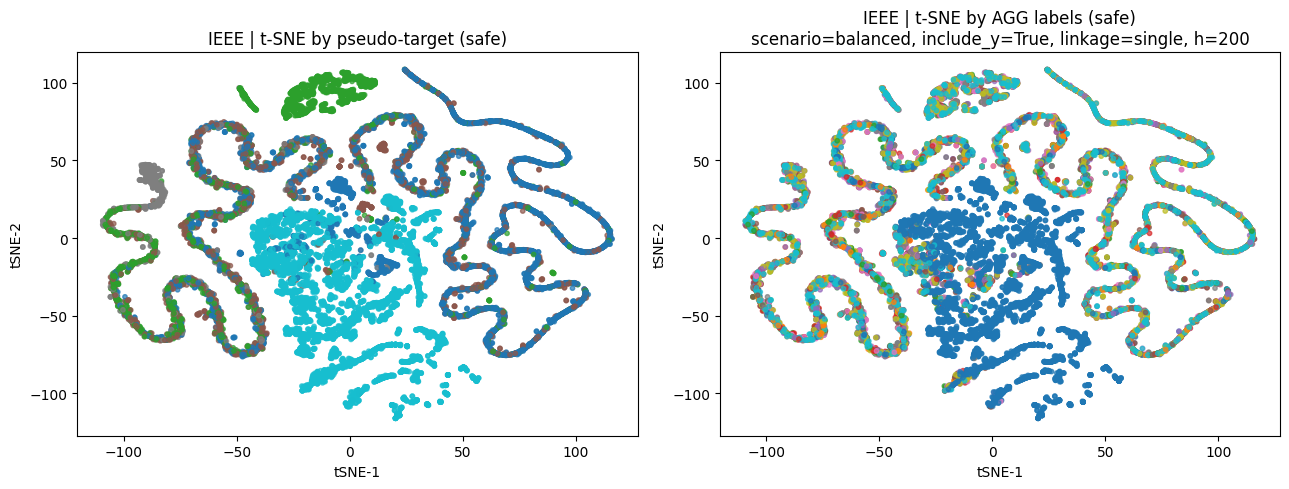

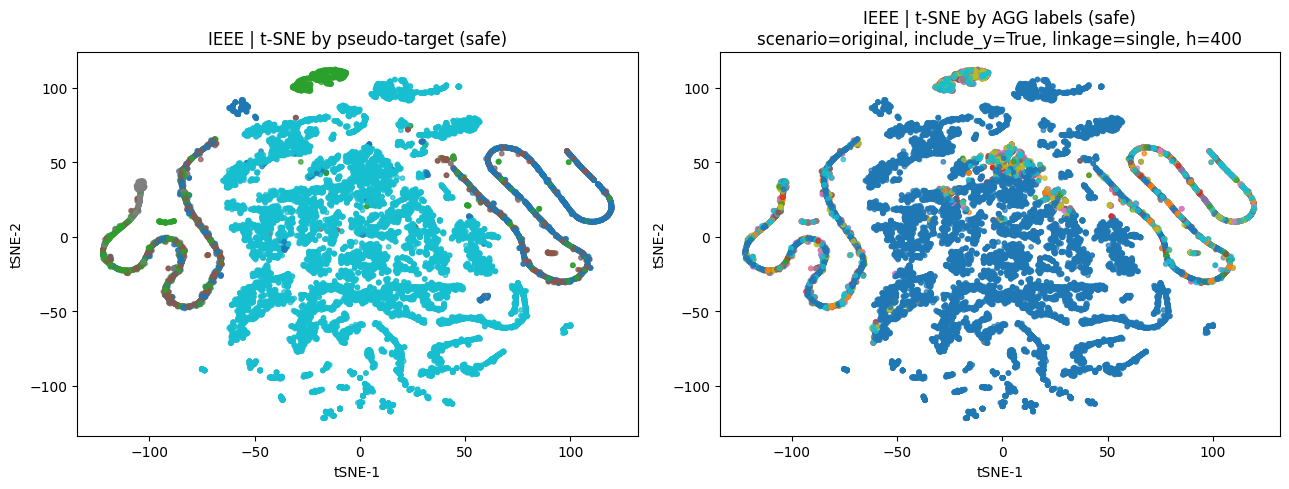

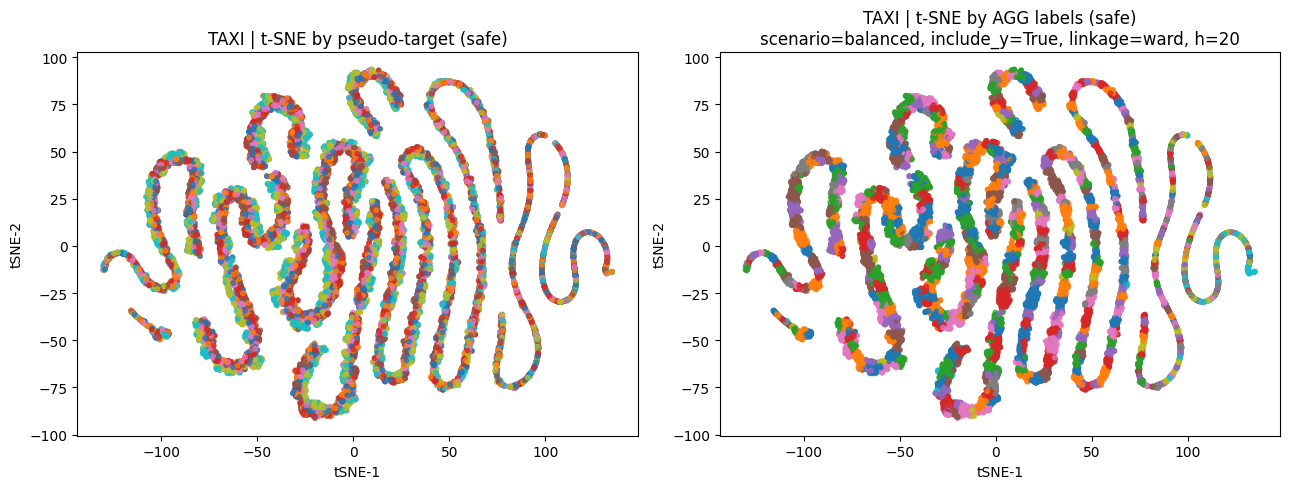

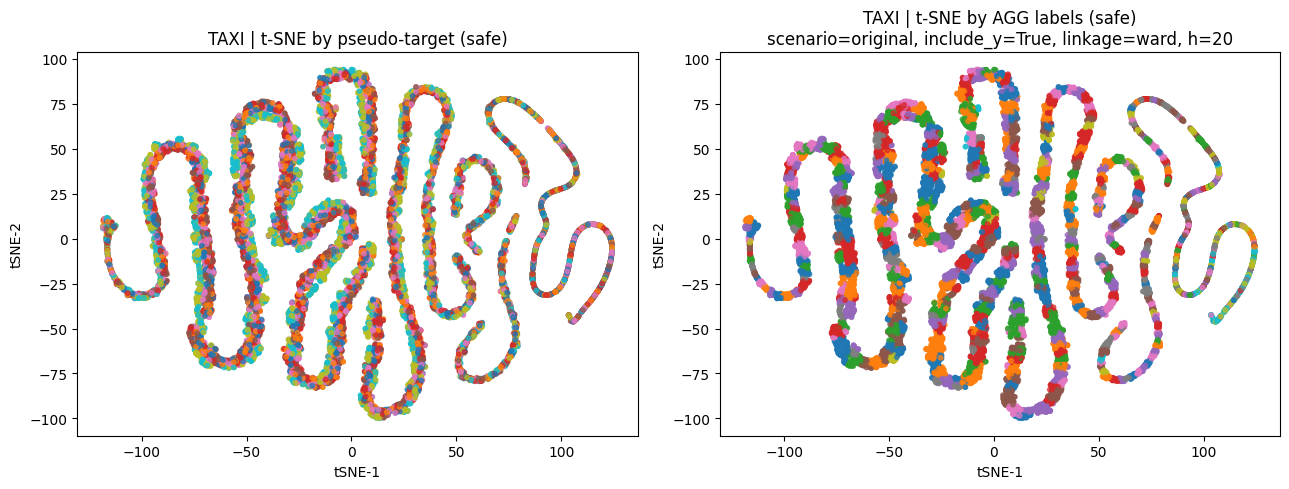

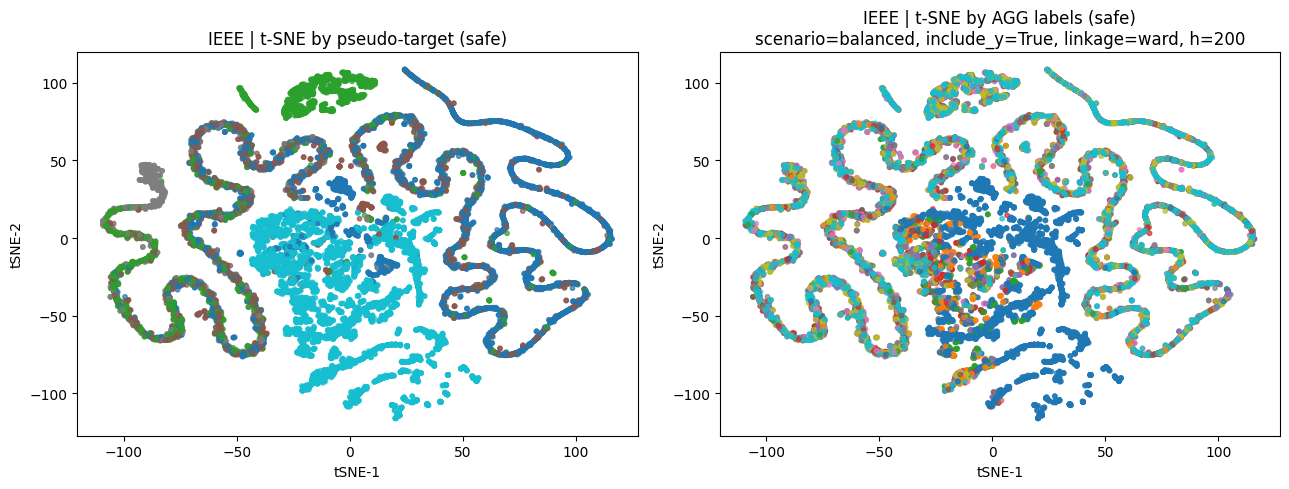

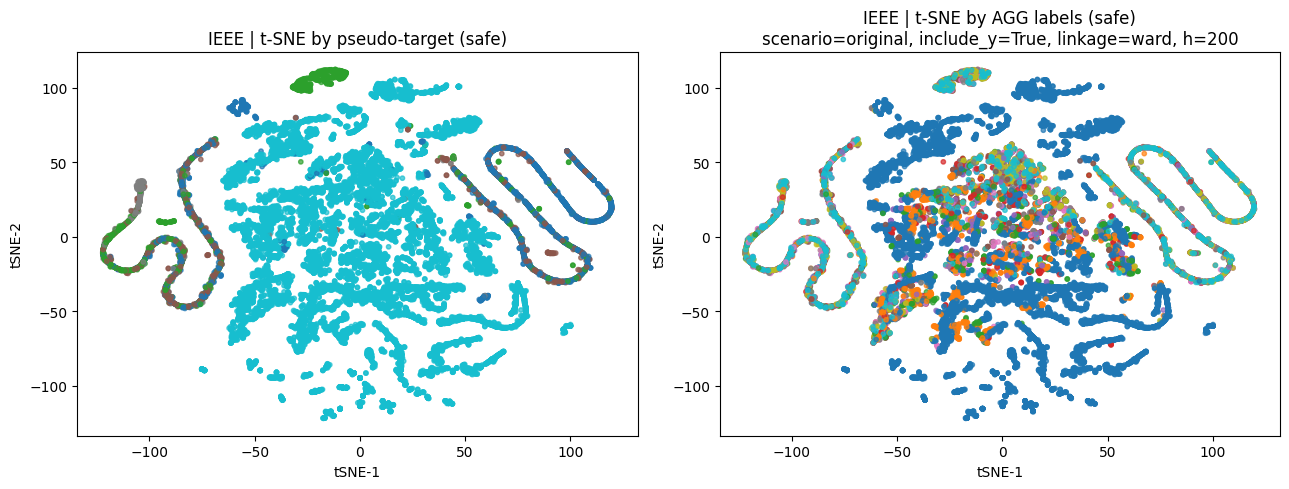

In [44]:
if len(agg_all_df_safe) == 0:
    print("No safe agglomerative results to visualize.")
else:
    agg_best_quality_safe = (
        agg_all_df_safe.sort_values(["dataset", "scenario", "include_y", "v_measure", "silhouette"], ascending=[True, True, True, False, False])
        .groupby(["dataset", "scenario", "include_y"], as_index=False)
        .first()
    )
    agg_best_balance_safe = (
        agg_all_df_safe.sort_values(["dataset", "scenario", "include_y", "cluster_imbalance_ratio", "largest_cluster_share", "v_measure"], ascending=[True, True, True, True, True, False])
        .groupby(["dataset", "scenario", "include_y"], as_index=False)
        .first()
    )

    tsne_cfgs_safe = pd.concat([agg_best_quality_safe, agg_best_balance_safe], ignore_index=True)
    tsne_cfgs_safe = tsne_cfgs_safe.drop_duplicates(subset=["dataset", "scenario", "include_y", "linkage", "distance_threshold"])

    agg_outputs_all_safe = {}
    agg_outputs_all_safe.update(agg_orig_with_y_out_safe)
    agg_outputs_all_safe.update(agg_bal_with_y_out_safe)

    for _, r in tsne_cfgs_safe.iterrows():
        key = (r["scenario"], bool(r["include_y"]), r["dataset"], r["linkage"], r["distance_threshold"])
        if key not in agg_outputs_all_safe:
            continue

        payload = agg_outputs_all_safe[key]
        X_np = payload["X_np"]
        labels = payload["labels"]
        y_pseudo = payload["y_pseudo"].astype(str)

        if len(X_np) > AGG_TSNE_MAX_POINTS:
            rng = np.random.default_rng(RANDOM_STATE)
            idx = rng.choice(len(X_np), size=AGG_TSNE_MAX_POINTS, replace=False)
            X_plot = X_np[idx]
            labels_plot = labels[idx]
            y_plot = y_pseudo.iloc[idx]
        else:
            X_plot = X_np
            labels_plot = labels
            y_plot = y_pseudo

        tsne = TSNE(n_components=2, random_state=RANDOM_STATE, init="pca", learning_rate="auto", perplexity=30)
        X_2d = tsne.fit_transform(X_plot)

        fig, axes = plt.subplots(1, 2, figsize=(13, 5))
        pseudo_cat = pd.Categorical(y_plot)

        axes[0].scatter(X_2d[:, 0], X_2d[:, 1], c=pseudo_cat.codes, s=10, alpha=0.7, cmap="tab10")
        axes[0].set_title(f"{r['dataset'].upper()} | t-SNE by pseudo-target (safe)")
        axes[0].set_xlabel("tSNE-1")
        axes[0].set_ylabel("tSNE-2")

        axes[1].scatter(X_2d[:, 0], X_2d[:, 1], c=labels_plot, s=10, alpha=0.7, cmap="tab10")
        axes[1].set_title(
            f"{r['dataset'].upper()} | t-SNE by AGG labels (safe)\n"
            f"scenario={r['scenario']}, include_y={r['include_y']}, linkage={r['linkage']}, h={r['distance_threshold']}"
        )
        axes[1].set_xlabel("tSNE-1")
        axes[1].set_ylabel("tSNE-2")

        plt.tight_layout()
        plt.show()

In [45]:
if len(agg_all_df_safe) == 0:
    print("No safe agglomerative results to visualize.")
else:
    target_k_by_dataset = {
        "taxi": int(X_taxi_cluster["tpep_pickup_dayofweek"].nunique(dropna=True)),
        "ieee": int(X_ieee_cluster["ProductCD_normalized"].nunique(dropna=True)),
    }

    agg_filtered_for_tsne = agg_all_df_safe.copy()
    agg_filtered_for_tsne = agg_filtered_for_tsne[
        agg_filtered_for_tsne["dataset"].isin(target_k_by_dataset.keys())
    ].copy()
    agg_filtered_for_tsne["target_k"] = agg_filtered_for_tsne["dataset"].map(target_k_by_dataset).astype(int)
    agg_filtered_for_tsne["n_clusters_found"] = agg_filtered_for_tsne["n_clusters_found"].astype(int)
    agg_filtered_for_tsne = agg_filtered_for_tsne[
        agg_filtered_for_tsne["n_clusters_found"] == agg_filtered_for_tsne["target_k"]
    ].copy()

    print(
        "Agg configs matching target k:",
        len(agg_filtered_for_tsne),
        "out of",
        len(agg_all_df_safe),
    )

    if len(agg_filtered_for_tsne) == 0:
        print("No safe agglomerative configs with k equal to pseudo-target class count.")
    else:
        agg_best_quality_safe = (
            agg_filtered_for_tsne.sort_values(["dataset", "scenario", "include_y", "v_measure", "silhouette"], ascending=[True, True, True, False, False])
            .groupby(["dataset", "scenario", "include_y"], as_index=False)
            .first()
        )
        agg_best_balance_safe = (
            agg_filtered_for_tsne.sort_values(["dataset", "scenario", "include_y", "cluster_imbalance_ratio", "largest_cluster_share", "v_measure"], ascending=[True, True, True, True, True, False])
            .groupby(["dataset", "scenario", "include_y"], as_index=False)
            .first()
        )

        tsne_cfgs_safe = pd.concat([agg_best_quality_safe, agg_best_balance_safe], ignore_index=True)
        tsne_cfgs_safe = tsne_cfgs_safe.drop_duplicates(subset=["dataset", "scenario", "include_y", "linkage", "distance_threshold"])

        agg_outputs_all_safe = {}
        agg_outputs_all_safe.update(agg_orig_with_y_out_safe)
        agg_outputs_all_safe.update(agg_bal_with_y_out_safe)

        plotted = 0
        for _, r in tsne_cfgs_safe.iterrows():
            key = (r["scenario"], bool(r["include_y"]), r["dataset"], r["linkage"], r["distance_threshold"])
            if key not in agg_outputs_all_safe:
                continue

            payload = agg_outputs_all_safe[key]
            X_np = payload["X_np"]
            labels = payload["labels"]
            y_pseudo = payload["y_pseudo"].astype(str)

            if len(X_np) > AGG_TSNE_MAX_POINTS:
                rng = np.random.default_rng(RANDOM_STATE)
                idx = rng.choice(len(X_np), size=AGG_TSNE_MAX_POINTS, replace=False)
                X_plot = X_np[idx]
                labels_plot = labels[idx]
                y_plot = y_pseudo.iloc[idx]
            else:
                X_plot = X_np
                labels_plot = labels
                y_plot = y_pseudo

            tsne = TSNE(n_components=2, random_state=RANDOM_STATE, init="pca", learning_rate="auto", perplexity=30)
            X_2d = tsne.fit_transform(X_plot)

            fig, axes = plt.subplots(1, 2, figsize=(13, 5))
            pseudo_cat = pd.Categorical(y_plot)

            axes[0].scatter(X_2d[:, 0], X_2d[:, 1], c=pseudo_cat.codes, s=10, alpha=0.7, cmap="tab10")
            axes[0].set_title(f"{r['dataset'].upper()} | t-SNE by pseudo-target (safe, k={int(r['n_clusters_found'])})")
            axes[0].set_xlabel("tSNE-1")
            axes[0].set_ylabel("tSNE-2")

            axes[1].scatter(X_2d[:, 0], X_2d[:, 1], c=labels_plot, s=10, alpha=0.7, cmap="tab10")
            axes[1].set_title(
                f"{r['dataset'].upper()} | t-SNE by AGG labels (safe)\\n"
                f"k={int(r['n_clusters_found'])}, scenario={r['scenario']}, include_y={r['include_y']}, linkage={r['linkage']}, h={r['distance_threshold']}"
            )
            axes[1].set_xlabel("tSNE-1")
            axes[1].set_ylabel("tSNE-2")

            plt.tight_layout()
            plt.show()
            plotted += 1

        print("Plotted safe t-SNE configs:", plotted)

Agg configs matching target k: 0 out of 64
No safe agglomerative configs with k equal to pseudo-target class count.


KMeans target-k configs for t-SNE:


,dataset,k,silhouette,v_measure
0,taxi,7,0.545115,0.003231
1,ieee,5,0.845521,0.419018


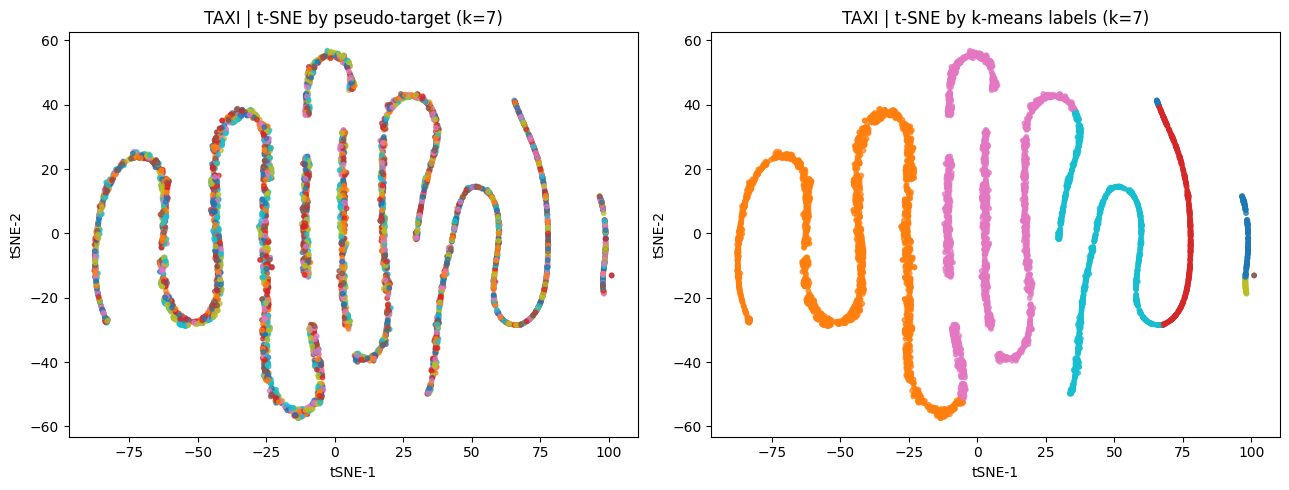

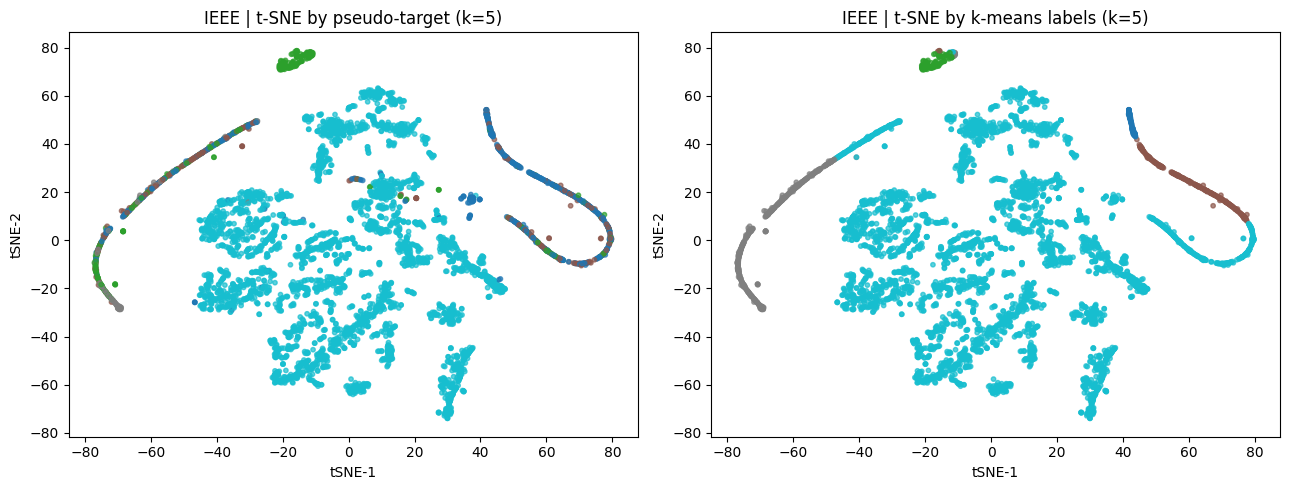

In [46]:
# t-SNE visualization for KMeans results (pseudo-target vs cluster labels)
from sklearn.manifold import TSNE

if "experiments_df" not in globals() or "cluster_outputs" not in globals():
    print("Run baseline KMeans block first (experiments_df + cluster_outputs are required).")
else:
    target_k_by_dataset = {
        "taxi": int(X_taxi_cluster["tpep_pickup_dayofweek"].nunique(dropna=True)),
        "ieee": int(X_ieee_cluster["ProductCD_normalized"].nunique(dropna=True)),
    }

    km_target_cfg_rows = []
    for dataset_name, k_target in target_k_by_dataset.items():
        row = experiments_df[(experiments_df["dataset"] == dataset_name) & (experiments_df["k"] == k_target)]
        if len(row) == 0:
            print(f"[WARN] Missing KMeans config for dataset={dataset_name}, k={k_target}.")
            continue
        km_target_cfg_rows.append(row.iloc[0][["dataset", "k", "silhouette", "v_measure"]])

    km_best_cfg = pd.DataFrame(km_target_cfg_rows).reset_index(drop=True)

    TSNE_MAX_POINTS_KMEANS = 5000

    print("KMeans target-k configs for t-SNE:")
    display(km_best_cfg)

    for _, row in km_best_cfg.iterrows():
        dataset_name = row["dataset"]
        k_best = int(row["k"])

        key = (dataset_name, k_best)
        if key not in cluster_outputs:
            print(f"[WARN] cluster_outputs has no key={key}, skipping.")
            continue

        payload = cluster_outputs[key]
        X_np = payload["X_np"]
        y_pseudo = payload["y_pseudo"].astype(str)
        labels = payload["labels"]

        if len(X_np) > TSNE_MAX_POINTS_KMEANS:
            rng = np.random.default_rng(RANDOM_STATE)
            idx = rng.choice(len(X_np), size=TSNE_MAX_POINTS_KMEANS, replace=False)
            X_plot = X_np[idx]
            labels_plot = labels[idx]
            y_plot = y_pseudo.iloc[idx]
        else:
            X_plot = X_np
            labels_plot = labels
            y_plot = y_pseudo

        tsne = TSNE(
            n_components=2,
            random_state=RANDOM_STATE,
            init="pca",
            learning_rate="auto",
            perplexity=30,
        )
        X_2d = tsne.fit_transform(X_plot)

        fig, axes = plt.subplots(1, 2, figsize=(13, 5))

        pseudo_cat = pd.Categorical(y_plot)
        axes[0].scatter(X_2d[:, 0], X_2d[:, 1], c=pseudo_cat.codes, s=10, alpha=0.7, cmap="tab10")
        axes[0].set_title(f"{dataset_name.upper()} | t-SNE by pseudo-target (k={k_best})")
        axes[0].set_xlabel("tSNE-1")
        axes[0].set_ylabel("tSNE-2")

        axes[1].scatter(X_2d[:, 0], X_2d[:, 1], c=labels_plot, s=10, alpha=0.7, cmap="tab10")
        axes[1].set_title(f"{dataset_name.upper()} | t-SNE by k-means labels (k={k_best})")
        axes[1].set_xlabel("tSNE-1")
        axes[1].set_ylabel("tSNE-2")

        plt.tight_layout()
        plt.show()

https://docs.google.com/spreadsheets/d/179NxlQQaoU_4LR5bdgVxgHPLNMWfEGEC5aOrzdSV8ag/edit?usp=sharing